# DATATHON 2026 - Final Kaggle Notebook

This notebook is fully self-contained for Kaggle: it trains the model, explains it, and writes `submission.csv` without importing local project files.

Pipeline summary:

- seasonal `(month, day)` baseline;
- CatBoost residual model on `log1p(target) - log1p(baseline)`;
- time-aware validation on 2021-2022;
- recursive 2023 -> 2024 forecasting;
- recent-regime calibration inferred from the latest annual rebound;
- CatBoost feature importance and built-in SHAP values;
- final Kaggle file: `submission.csv`.

## 1. Imports, Config, and Modeling Functions

All code needed for training and inference is defined inside this notebook. No external `.py` file is imported.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
DATA_CANDIDATES = [Path.cwd() / "data", Path.cwd()]
if Path("/kaggle/input").exists():
    DATA_CANDIDATES += [p.parent for p in Path("/kaggle/input").rglob("sales.csv")]
DATA_DIR = next(
    p for p in DATA_CANDIDATES
    if (p / "sales.csv").exists() and (p / "sample_submission.csv").exists()
)
SEED = 42
VALID_YEARS = [2021, 2022]

NUM_COLS = [
    "year",
    "month",
    "day",
    "dow",
    "doy",
    "woy",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_quarter_start",
    "is_quarter_end",
    "days_to_month_end",
    "week_of_month",
    "is_first_3_days",
    "is_last_3_days",
    "is_first_7_days",
    "is_last_7_days",
    "is_payday_window",
    "t",
    "sin_1",
    "cos_1",
    "sin_2",
    "cos_2",
    "sin_3",
    "cos_3",
    "spring",
    "midyear",
    "fall",
    "yearend",
    "urban",
    "rural",
    "promo_any",
    "weekend_promo",
    "baseline",
    "lag1",
    "lag2",
    "lag3",
    "md_mean",
    "md_recent",
    "dow_mean",
    "month_mean",
    "wom_mean",
    "lag_mean",
    "lag_std",
    "lag_missing",
]
CAT_COLS = ["dow_month", "month_pos"]
FEATURE_COLS = NUM_COLS + CAT_COLS


def regime_controls(sales: pd.DataFrame) -> dict[str, float]:
    """Return stable level controls for the most recent demand regime.

    The model is trained on a long history that includes a structural drop
    around 2019 and a rebound in 2022. These controls keep the first forecast
    year aligned to the recent rebound, then temper the recursively generated
    second-year level while keeping its learned day-to-day shape.
    """
    annual_revenue = sales.groupby(sales["Date"].dt.year)["Revenue"].sum().sort_index()
    latest_rebound = annual_revenue.iloc[-1] / annual_revenue.iloc[-2]
    bridge_year_level = float(np.clip(latest_rebound * 1.08, 1.05, 1.25))
    recursive_year_level = float(np.clip(1.0 / (bridge_year_level**2), 0.62, 0.78))
    return {
        "bridge_year_level": bridge_year_level,
        "recursive_year_level": recursive_year_level,
    }


def load_sales() -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)


def load_sample() -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / "sample_submission.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)


def clipped_growth(series: pd.Series, recent_years: int = 4, lo: float = 0.92, hi: float = 1.12) -> float:
    yoy = series.pct_change().dropna().tail(recent_years)
    if len(yoy) == 0:
        growth = 1.0
    else:
        growth = float((1 + yoy).prod() ** (1 / len(yoy)))
    return min(max(growth, lo), hi)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df["Date"]
    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["dow"] = dt.dt.dayofweek
    df["doy"] = dt.dt.dayofyear
    df["woy"] = dt.dt.isocalendar().week.astype(int)
    df["quarter"] = dt.dt.quarter
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["is_month_start"] = dt.dt.is_month_start.astype(int)
    df["is_month_end"] = dt.dt.is_month_end.astype(int)
    df["is_quarter_start"] = dt.dt.is_quarter_start.astype(int)
    df["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)
    df["days_in_month"] = dt.dt.days_in_month
    df["days_to_month_end"] = df["days_in_month"] - df["day"]
    df["week_of_month"] = ((df["day"] - 1) // 7 + 1).astype(int)
    df["is_first_3_days"] = (df["day"] <= 3).astype(int)
    df["is_last_3_days"] = (df["days_to_month_end"] <= 2).astype(int)
    df["is_first_7_days"] = (df["day"] <= 7).astype(int)
    df["is_last_7_days"] = (df["days_to_month_end"] <= 6).astype(int)
    df["is_payday_window"] = df["day"].isin([1, 2, 3, 27, 28, 29, 30, 31]).astype(int)
    df["t"] = (dt - pd.Timestamp("2012-07-04")).dt.days

    for k in [1, 2, 3]:
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * df["doy"] / 365.25)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * df["doy"] / 365.25)

    md = dt.dt.strftime("%m-%d")
    df["spring"] = ((md >= "03-18") & (md <= "04-17")).astype(int)
    df["midyear"] = ((md >= "06-23") & (md <= "07-22")).astype(int)
    df["fall"] = ((md >= "08-30") & (md <= "10-02")).astype(int)
    df["yearend"] = ((md >= "11-18") | (md <= "01-02")).astype(int)
    df["urban"] = ((md >= "07-30") & (md <= "09-02")).astype(int)
    df["rural"] = ((md >= "01-30") & (md <= "03-01")).astype(int)
    df["promo_any"] = df[["spring", "midyear", "fall", "yearend", "urban", "rural"]].max(axis=1)
    df["weekend_promo"] = (df["is_weekend"] * df["promo_any"]).astype(int)
    df["dow_month"] = df["dow"].astype(str) + "_" + df["month"].astype(str)
    df["month_pos"] = pd.cut(
        df["day"],
        bins=[0, 5, 10, 15, 20, 25, 31],
        labels=["p1", "p2", "p3", "p4", "p5", "p6"],
    ).astype(str)
    return df


def seasonal_baseline(history: pd.DataFrame, future_dates: pd.DataFrame, target: str) -> pd.Series:
    hist = history.copy()
    hist["year"] = hist["Date"].dt.year
    hist["month"] = hist["Date"].dt.month
    hist["day"] = hist["Date"].dt.day

    annual = hist.groupby("year")[target].sum().sort_index()
    growth = clipped_growth(annual)
    annual_mean = hist.groupby("year")[target].transform("mean")
    hist["norm"] = hist[target] / annual_mean
    seasonal = hist.groupby(["month", "day"])["norm"].mean()

    base_year = int(annual.index.max())
    days_in_base_year = 366 if pd.Timestamp(f"{base_year}-12-31").is_leap_year else 365
    base_level = annual.loc[base_year] / days_in_base_year

    fut = future_dates.copy()
    fut["year"] = fut["Date"].dt.year
    fut["month"] = fut["Date"].dt.month
    fut["day"] = fut["Date"].dt.day
    fut["years_ahead"] = fut["year"] - base_year
    season = fut.set_index(["month", "day"]).index.map(seasonal).astype(float)
    season = pd.Series(season, index=fut.index).fillna(1.0)
    return base_level * (growth ** fut["years_ahead"]) * season


def build_yearly_feature_frame(sales: pd.DataFrame, target: str, forecast_year: int) -> pd.DataFrame:
    hist = add_features(sales[["Date", target]].copy())
    prior = hist[hist["year"] < forecast_year].copy()
    current = hist[hist["year"] == forecast_year].copy()
    if current.empty or prior.empty:
        return pd.DataFrame()

    current["baseline"] = seasonal_baseline(prior[["Date", target]], current[["Date"]], target).values
    yearly_map = prior.groupby(["year", "month", "day"])[target].mean()
    for lag in [1, 2, 3]:
        current[f"lag{lag}"] = [
            yearly_map.get((forecast_year - lag, int(m), int(d)), np.nan)
            for m, d in zip(current["month"], current["day"])
        ]

    md_mean = prior.groupby(["month", "day"])[target].mean()
    md_recent = prior[prior["year"] >= max(prior["year"].max() - 1, prior["year"].min())].groupby(["month", "day"])[target].mean()
    dow_mean = prior.groupby("dow")[target].mean()
    month_mean = prior.groupby("month")[target].mean()
    wom_mean = prior.groupby(["month", "week_of_month"])[target].mean()

    current["md_mean"] = [md_mean.get((m, d), np.nan) for m, d in zip(current["month"], current["day"])]
    current["md_recent"] = [md_recent.get((m, d), np.nan) for m, d in zip(current["month"], current["day"])]
    current["dow_mean"] = current["dow"].map(dow_mean)
    current["month_mean"] = current["month"].map(month_mean)
    current["wom_mean"] = [wom_mean.get((m, w), np.nan) for m, w in zip(current["month"], current["week_of_month"])]
    current["lag_mean"] = current[["lag1", "lag2", "lag3"]].mean(axis=1)
    current["lag_std"] = current[["lag1", "lag2", "lag3"]].std(axis=1)
    current["lag_missing"] = current[["lag1", "lag2", "lag3"]].isna().sum(axis=1)
    current["target"] = current[target]
    return current


def build_future_frame(history: pd.DataFrame, target: str, future_dates: pd.DataFrame) -> pd.DataFrame:
    combined = pd.concat(
        [history[["Date", target]], future_dates[["Date"]]],
        ignore_index=True,
    ).sort_values("Date").reset_index(drop=True)
    frames = []
    for year in sorted(future_dates["Date"].dt.year.unique()):
        frame = build_yearly_feature_frame(combined, target, int(year))
        frame = frame[frame["Date"].isin(future_dates["Date"])]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def sample_weights(years: pd.Series) -> np.ndarray:
    weight_map = {
        2015: 0.35,
        2016: 0.45,
        2017: 0.60,
        2018: 0.80,
        2019: 1.00,
        2020: 1.15,
        2021: 1.35,
        2022: 1.55,
    }
    return years.map(weight_map).fillna(1.0).values


def prepare_xy(train_frame: pd.DataFrame, predict_frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, list[int]]:
    Xtr = train_frame[FEATURE_COLS].copy()
    Xpr = predict_frame[FEATURE_COLS].copy()
    ytr = np.log1p(train_frame["target"]) - np.log1p(train_frame["baseline"])

    med = Xtr[NUM_COLS].median()
    Xtr[NUM_COLS] = Xtr[NUM_COLS].fillna(med)
    Xpr[NUM_COLS] = Xpr[NUM_COLS].fillna(med)
    for col in CAT_COLS:
        Xtr[col] = Xtr[col].astype(str)
        Xpr[col] = Xpr[col].astype(str)
    cat_idx = [Xtr.columns.get_loc(c) for c in CAT_COLS]
    return Xtr, Xpr, ytr, cat_idx


def fit_model(train_frame: pd.DataFrame) -> tuple[CatBoostRegressor, pd.Series]:
    Xtr, _, ytr, cat_idx = prepare_xy(train_frame, train_frame)
    model = CatBoostRegressor(
        loss_function="RMSE",
        iterations=900,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6.0,
        random_seed=SEED,
        verbose=False,
    )
    model.fit(
        Xtr,
        ytr,
        cat_features=cat_idx,
        sample_weight=sample_weights(train_frame["year"]),
    )
    return model, Xtr.median(numeric_only=True)


def fit_predict(train_frame: pd.DataFrame, predict_frame: pd.DataFrame) -> tuple[np.ndarray, CatBoostRegressor, pd.DataFrame]:
    Xtr, Xpr, ytr, cat_idx = prepare_xy(train_frame, predict_frame)
    model = CatBoostRegressor(
        loss_function="RMSE",
        iterations=900,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6.0,
        random_seed=SEED,
        verbose=False,
    )
    model.fit(
        Xtr,
        ytr,
        cat_features=cat_idx,
        sample_weight=sample_weights(train_frame["year"]),
    )
    residual = model.predict(Xpr)
    pred = np.expm1(np.log1p(predict_frame["baseline"]) + residual)
    return pred, model, Xpr


def evaluate_recent_cv(sales: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target in ["Revenue", "COGS"]:
        for valid_year in VALID_YEARS:
            train = pd.concat(
                [build_yearly_feature_frame(sales, target, y) for y in range(2015, valid_year)],
                ignore_index=True,
            )
            valid = build_yearly_feature_frame(sales, target, valid_year)
            pred, _, _ = fit_predict(train, valid)
            rows.append(
                {
                    "target": target,
                    "valid_year": valid_year,
                    "MAE": mean_absolute_error(valid["target"], pred),
                    "RMSE": mean_squared_error(valid["target"], pred) ** 0.5,
                    "R2": r2_score(valid["target"], pred),
                }
            )
    return pd.DataFrame(rows)


def feature_importance(model: CatBoostRegressor, target: str, year: int) -> pd.DataFrame:
    return (
        pd.DataFrame(
            {
                "target": target,
                "forecast_year": year,
                "feature": FEATURE_COLS,
                "importance": model.get_feature_importance(type="PredictionValuesChange"),
            }
        )
        .sort_values(["target", "importance"], ascending=[True, False])
        .reset_index(drop=True)
    )


def calibrated_recursive_forecast(sales: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    controls = regime_controls(sales)
    sample = load_sample()
    future_2023 = sample[sample["Date"].dt.year == 2023][["Date"]].copy().reset_index(drop=True)
    future_2024 = sample[sample["Date"].dt.year == 2024][["Date"]].copy().reset_index(drop=True)
    part_2023 = future_2023.copy()
    part_2024 = future_2024.copy()
    importance_frames = []

    for target in ["Revenue", "COGS"]:
        train_2023 = pd.concat(
            [build_yearly_feature_frame(sales, target, y) for y in range(2015, 2023)],
            ignore_index=True,
        )
        frame_2023 = build_future_frame(sales[["Date", target]], target, future_2023)
        pred_2023, _, _ = fit_predict(train_2023, frame_2023)
        part_2023[target] = pred_2023 * controls["bridge_year_level"]

        history_2024 = pd.concat(
            [sales[["Date", target]], part_2023[["Date", target]]],
            ignore_index=True,
        ).sort_values("Date").reset_index(drop=True)
        train_2024 = pd.concat(
            [build_yearly_feature_frame(history_2024, target, y) for y in range(2015, 2024)],
            ignore_index=True,
        )
        frame_2024 = build_future_frame(history_2024, target, future_2024)
        pred_2024, model_2024, _ = fit_predict(train_2024, frame_2024)
        part_2024[target] = pred_2024
        importance_frames.append(feature_importance(model_2024, target, 2024))

    submission = pd.concat([part_2023, part_2024], ignore_index=True).sort_values("Date").reset_index(drop=True)

    ratio_hist = (sales["COGS"] / sales["Revenue"]).replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = ratio_hist.quantile([0.02, 0.98]).tolist()
    submission["margin_ratio"] = (submission["COGS"] / submission["Revenue"]).clip(lower=lo, upper=hi)
    submission["COGS"] = submission["Revenue"] * submission["margin_ratio"]
    submission = submission.drop(columns=["margin_ratio"])

    # Apply conservative second-year level damping after margin clipping so the
    # recursive model contributes shape, while the final level stays stable.
    mask_2024 = submission["Date"].dt.year == 2024
    submission.loc[mask_2024, ["Revenue", "COGS"]] *= controls["recursive_year_level"]

    submission["Revenue"] = submission["Revenue"].clip(lower=0).round(2)
    submission["COGS"] = submission["COGS"].clip(lower=0).round(2)
    submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

    importance = pd.concat(importance_frames, ignore_index=True)
    return submission, importance


def validate_submission(submission: pd.DataFrame) -> None:
    sample = load_sample()
    assert len(submission) == len(sample), "Wrong row count"
    assert submission["Date"].equals(sample["Date"].dt.strftime("%Y-%m-%d")), "Date order differs from sample_submission"
    assert not submission[["Revenue", "COGS"]].isna().any().any(), "Submission contains missing values"
    assert (submission[["Revenue", "COGS"]] >= 0).all().all(), "Submission contains negative predictions"


def run(run_cv: bool = True) -> pd.DataFrame:
    np.random.seed(SEED)
    sales = load_sales()

    if run_cv:
        cv = evaluate_recent_cv(sales)
        cv.to_csv("final_validation_recent_cv.csv", index=False)
        print("Recent CV summary")
        print(cv.groupby("target")[["MAE", "RMSE", "R2"]].mean().round(4).to_string())

    submission, importance = calibrated_recursive_forecast(sales)
    validate_submission(submission)
    submission.to_csv("submission_final.csv", index=False)
    submission.to_csv("submission.csv", index=False)
    importance.to_csv("final_feature_importance.csv", index=False)

    print("Saved submission_final.csv")
    print("Saved submission.csv")
    print("Saved final_feature_importance.csv")
    print("Top explanatory features")
    print(importance.groupby("target").head(10).round(4).to_string(index=False))
    return submission


print(f"Working directory: {ROOT}")
print(f"Data directory: {DATA_DIR}")


Working directory: /kaggle/working
Data directory: /kaggle/input/competitions/datathon-2026-round-1


## 2. Train Models and Create Kaggle Submission

This cell runs the full training and inference pipeline and writes `submission.csv` in the working directory.

In [2]:
submission = run(run_cv=True)

submission_path = "submission.csv"
final_path = "submission_final.csv"
print(f"Kaggle submission file: {submission_path}")
print(f"Research artifact file: {final_path}")
submission.head(10)

Recent CV summary
                 MAE         RMSE      R2
target                                   
COGS     526061.3131  721030.4844  0.7493
Revenue  608816.9978  842137.0240  0.7420
Saved submission_final.csv
Saved submission.csv
Saved final_feature_importance.csv
Top explanatory features
 target  forecast_year    feature  importance
Revenue           2024          t     27.5993
Revenue           2024       year     16.3659
Revenue           2024 month_mean      5.7534
Revenue           2024  dow_month      4.9882
Revenue           2024   dow_mean      4.4916
Revenue           2024        dow      4.1375
Revenue           2024       lag3      3.6037
Revenue           2024    lag_std      2.8928
Revenue           2024      sin_2      2.3012
Revenue           2024      urban      2.0983
   COGS           2024          t     29.7080
   COGS           2024       year     15.2901
   COGS           2024  dow_month      5.3275
   COGS           2024        dow      5.0967
   COGS         

,Date,Revenue,COGS
0,2023-01-01,3490326.78,3029331.73
1,2023-01-02,1625355.78,1242414.22
2,2023-01-03,1402603.12,1072143.15
3,2023-01-04,1464659.13,1119578.46
4,2023-01-05,1395244.32,1066518.12
5,2023-01-06,1667688.76,1274773.35
6,2023-01-07,2097831.75,1603572.61
7,2023-01-08,2122876.33,1935134.89
8,2023-01-09,2302817.19,2166300.35
9,2023-01-10,2256608.12,1724940.51


## 3. Validation Metrics

Validation uses 2021-2022 because this period is closer to the recent demand regime than the early history. The competition reports MAE, RMSE, and R?.

,target,valid_year,MAE,RMSE,R2
0,Revenue,2021,592042.914382,827191.185336,0.746165
1,Revenue,2022,625591.081283,857082.862629,0.737800
2,COGS,2021,547537.550951,776095.383409,0.707075
3,COGS,2022,504585.075226,665965.585298,0.791527


,target,MAE,RMSE,R2
0,COGS,526061.313089,721030.484353,0.749301
1,Revenue,608816.997832,842137.023983,0.741982


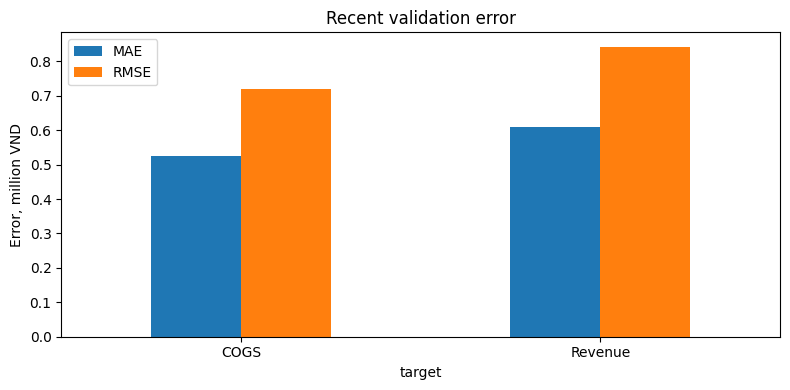

In [3]:
cv = pd.read_csv("final_validation_recent_cv.csv")
cv_summary = cv.groupby("target")[["MAE", "RMSE", "R2"]].mean().reset_index()
display(cv)
display(cv_summary)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = cv_summary.set_index("target")[["MAE", "RMSE"]] / 1_000_000
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Error, million VND")
ax.set_title("Recent validation error")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

## 4. Forecast Sanity Check

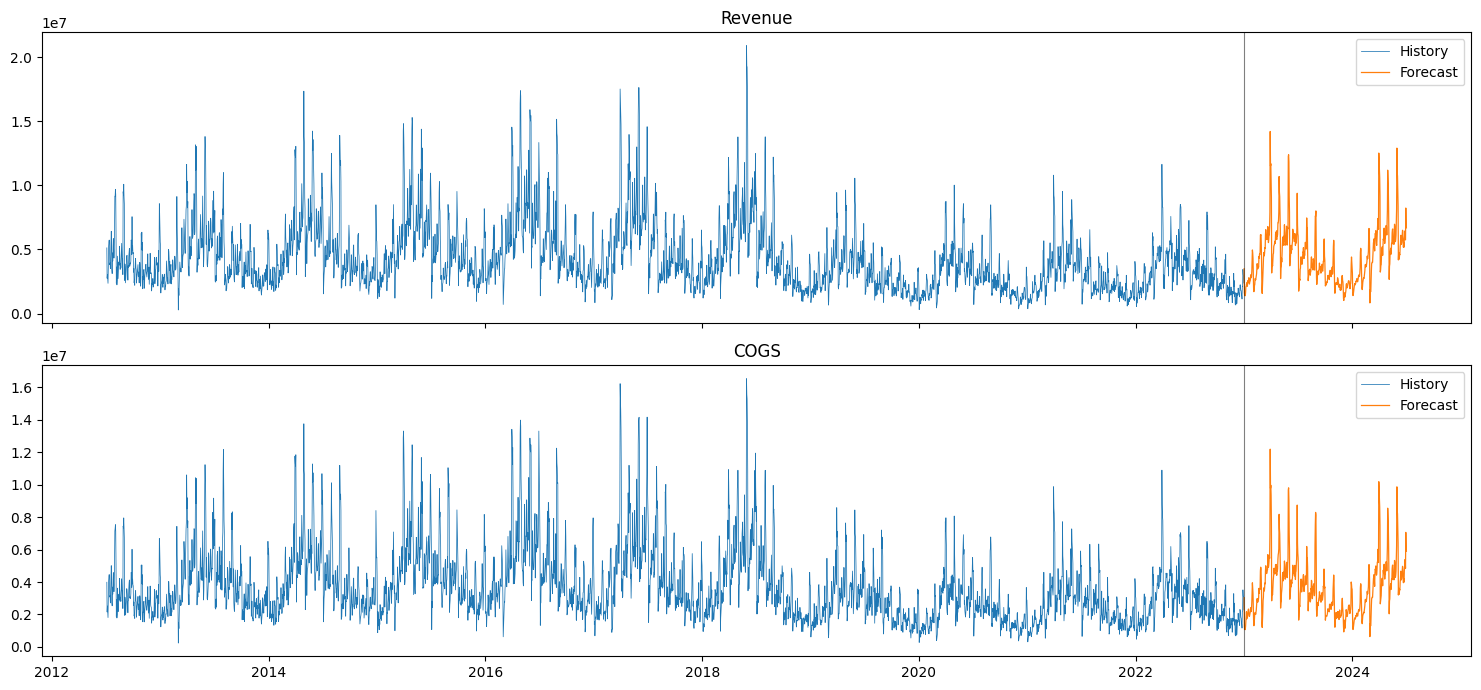

In [4]:
sales = load_sales()
plot_sub = pd.read_csv("submission_final.csv", parse_dates=["Date"])

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
for ax, target in zip(axes, ["Revenue", "COGS"]):
    ax.plot(sales["Date"], sales[target], lw=0.55, label="History")
    ax.plot(plot_sub["Date"], plot_sub[target], lw=0.9, label="Forecast")
    ax.axvline(pd.Timestamp("2023-01-01"), color="black", lw=0.8, alpha=0.5)
    ax.set_title(target)
    ax.legend()
plt.tight_layout()

## 5. Feature Importance

CatBoost `PredictionValuesChange` importance gives a model-native explanation of the strongest predictive features.

,target,forecast_year,feature,importance
0,Revenue,2024,t,27.599345
1,Revenue,2024,year,16.365925
2,Revenue,2024,month_mean,5.753431
3,Revenue,2024,dow_month,4.988192
4,Revenue,2024,dow_mean,4.491627
5,Revenue,2024,dow,4.137492
6,Revenue,2024,lag3,3.603663
7,Revenue,2024,lag_std,2.892783
8,Revenue,2024,sin_2,2.301166
9,Revenue,2024,urban,2.098285


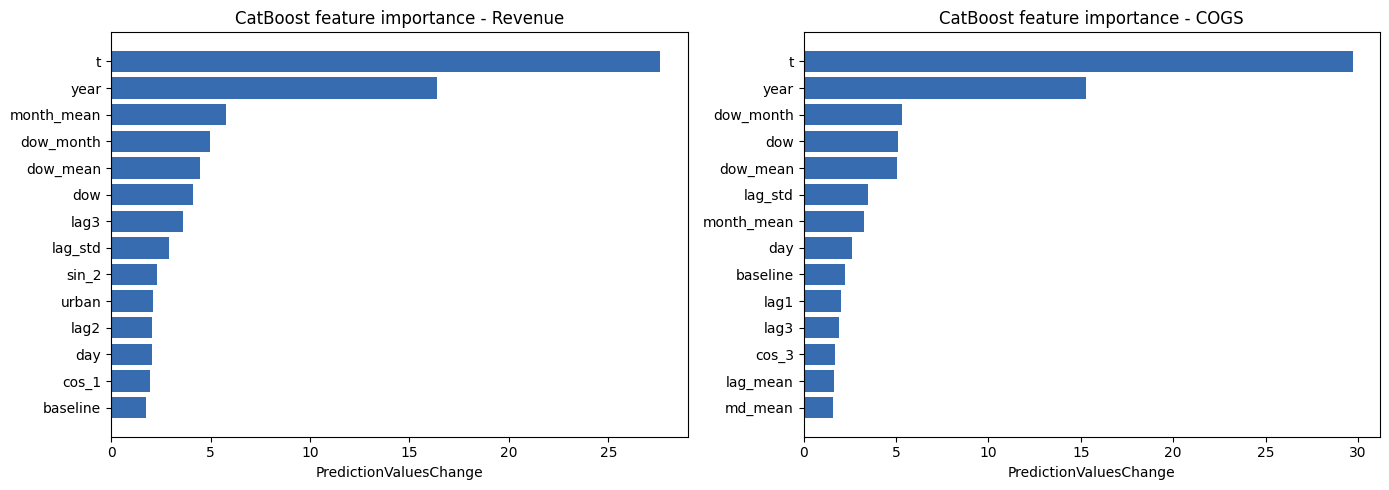

In [5]:
imp = pd.read_csv("final_feature_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ["Revenue", "COGS"]):
    top = imp[imp["target"] == target].nlargest(14, "importance").sort_values("importance")
    ax.barh(top["feature"], top["importance"], color="#386cb0")
    ax.set_title(f"CatBoost feature importance - {target}")
    ax.set_xlabel("PredictionValuesChange")
plt.tight_layout()

display(imp.groupby("target").head(12))

## 6. SHAP Explanation

This section uses CatBoost built-in SHAP values, so no external `shap` dependency is required. It retrains the final 2024 models exactly as in the production pipeline and computes SHAP values on sampled 2024 forecast rows.

,target,feature,mean_abs_shap
67,COGS,t,0.174866
48,COGS,year,0.135366
94,COGS,dow_month,0.025859
51,COGS,dow,0.021580
92,COGS,lag_std,0.019671
82,COGS,baseline,0.017352
85,COGS,lag3,0.011855
90,COGS,wom_mean,0.011225
88,COGS,dow_mean,0.009953
50,COGS,day,0.009867


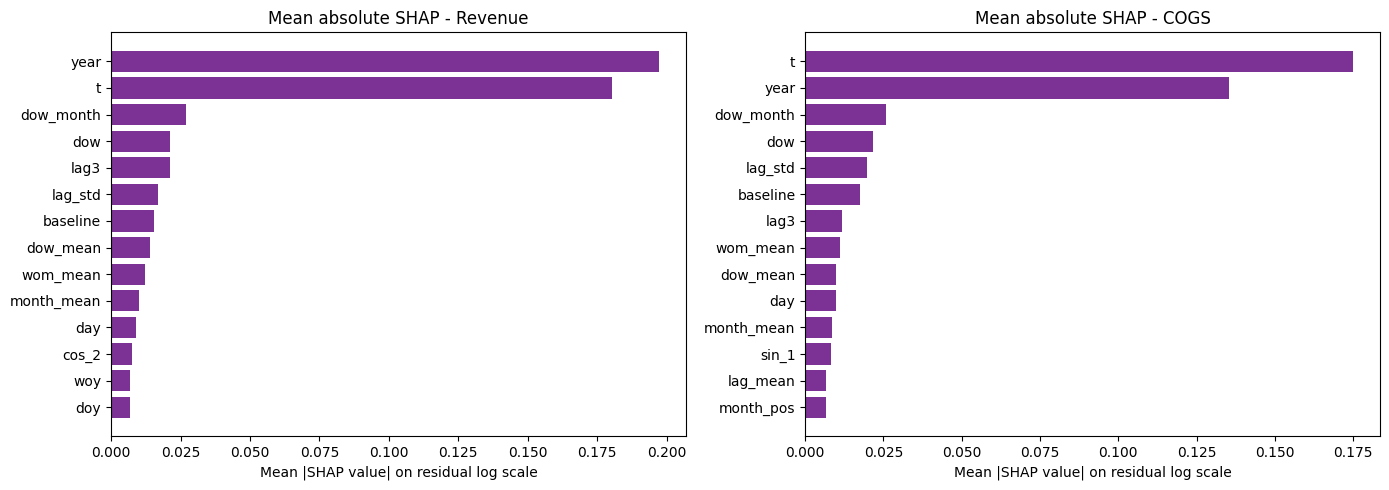

In [6]:
def build_2024_explainer_frames():
    sales = load_sales()
    sample = load_sample()
    controls = regime_controls(sales)
    future_2023 = sample[sample["Date"].dt.year == 2023][["Date"]].copy().reset_index(drop=True)
    future_2024 = sample[sample["Date"].dt.year == 2024][["Date"]].copy().reset_index(drop=True)

    part_2023 = future_2023.copy()
    explainers = {}

    for target in ["Revenue", "COGS"]:
        train_2023 = pd.concat(
            [build_yearly_feature_frame(sales, target, y) for y in range(2015, 2023)],
            ignore_index=True,
        )
        frame_2023 = build_future_frame(sales[["Date", target]], target, future_2023)
        pred_2023, _, _ = fit_predict(train_2023, frame_2023)
        part_2023[target] = pred_2023 * controls["bridge_year_level"]

        history_2024 = pd.concat(
            [sales[["Date", target]], part_2023[["Date", target]]],
            ignore_index=True,
        ).sort_values("Date").reset_index(drop=True)
        train_2024 = pd.concat(
            [build_yearly_feature_frame(history_2024, target, y) for y in range(2015, 2024)],
            ignore_index=True,
        )
        frame_2024 = build_future_frame(history_2024, target, future_2024)
        _, model_2024, X_2024 = fit_predict(train_2024, frame_2024)
        explainers[target] = (model_2024, X_2024)

    return explainers

explainers = build_2024_explainer_frames()
shap_rows = []

for target, (model, X_2024) in explainers.items():
    X_sample = X_2024.sample(min(160, len(X_2024)), random_state=SEED).reset_index(drop=True)
    cat_idx = [X_sample.columns.get_loc(c) for c in CAT_COLS]
    pool = Pool(X_sample, cat_features=cat_idx)
    shap_values = model.get_feature_importance(pool, type="ShapValues")[:, :-1]
    mean_abs = np.abs(shap_values).mean(axis=0)

    for feature, value in zip(X_sample.columns, mean_abs):
        shap_rows.append({"target": target, "feature": feature, "mean_abs_shap": value})

shap_summary = pd.DataFrame(shap_rows).sort_values(["target", "mean_abs_shap"], ascending=[True, False])
shap_summary.to_csv("final_shap_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ["Revenue", "COGS"]):
    top = shap_summary[shap_summary["target"] == target].nlargest(14, "mean_abs_shap").sort_values("mean_abs_shap")
    ax.barh(top["feature"], top["mean_abs_shap"], color="#7b3294")
    ax.set_title(f"Mean absolute SHAP - {target}")
    ax.set_xlabel("Mean |SHAP value| on residual log scale")
plt.tight_layout()

display(shap_summary.groupby("target").head(12))

## 7. SHAP Direction Check

A compact SHAP distribution plot for top Revenue features. Positive values push the residual forecast upward; negative values push it downward.

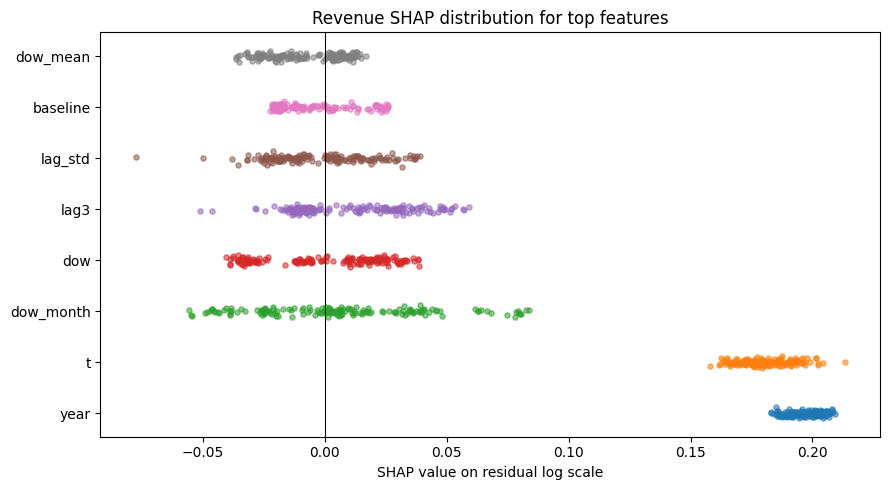

In [7]:
target = "Revenue"
model, X_2024 = explainers[target]
X_sample = X_2024.sample(min(160, len(X_2024)), random_state=SEED).reset_index(drop=True)
cat_idx = [X_sample.columns.get_loc(c) for c in CAT_COLS]
shap_values = model.get_feature_importance(Pool(X_sample, cat_features=cat_idx), type="ShapValues")[:, :-1]

top_features = (
    shap_summary[shap_summary["target"] == target]
    .nlargest(8, "mean_abs_shap")["feature"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9, 5))
rng = np.random.default_rng(SEED)
for i, feature in enumerate(top_features):
    j = X_sample.columns.get_loc(feature)
    y = np.full(len(X_sample), i) + rng.normal(0, 0.045, len(X_sample))
    ax.scatter(shap_values[:, j], y, s=14, alpha=0.55)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.set_xlabel("SHAP value on residual log scale")
ax.set_title("Revenue SHAP distribution for top features")
plt.tight_layout()

## 8. Submission Checks

The final file must match the order and row count of `sample_submission.csv`.

In [8]:
sample = load_sample()
final_sub = pd.read_csv("submission.csv")
checks = {
    "rows": len(final_sub),
    "expected_rows": len(sample),
    "date_order_ok": final_sub["Date"].equals(sample["Date"].dt.strftime("%Y-%m-%d")),
    "missing_values": int(final_sub[["Revenue", "COGS"]].isna().sum().sum()),
    "negative_values": int((final_sub[["Revenue", "COGS"]] < 0).sum().sum()),
}
checks

{'rows': 548,
 'expected_rows': 548,
 'date_order_ok': True,
 'missing_values': 0,
 'negative_values': 0}

## 9. Final Kaggle Output

In [9]:
kaggle_submission = pd.read_csv("submission.csv")
print("Submit this file: submission.csv")
print(kaggle_submission.shape)
kaggle_submission.head()

Submit this file: submission.csv
(548, 3)


,Date,Revenue,COGS
0,2023-01-01,3490326.78,3029331.73
1,2023-01-02,1625355.78,1242414.22
2,2023-01-03,1402603.12,1072143.15
3,2023-01-04,1464659.13,1119578.46
4,2023-01-05,1395244.32,1066518.12


## 10. Business Explanation

The final model is structured as baseline plus residual correction. The seasonal baseline captures stable yearly patterns, while CatBoost learns deviations from calendar, event-window, weekday, month-position, and lag features.

The explanation artifacts show that the strongest drivers are trend/recent-regime level, weekday interactions, yearly lag behavior, month-level demand, and campaign windows. The recursive forecast uses the 2023 prediction as history for 2024, with conservative recent-regime damping so 2024 keeps the model's learned daily shape without over-amplifying the level.